# Identificación y Entrenamiento del Clasificador de Quejas


## 1. Carga de datos y librerías

Importamos las librerías necesarias y cargamos los datos de quejas de clientes.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import re
import warnings
warnings.filterwarnings("ignore")

# Cargar datos
df = pd.read_excel(r"../data/BD_Quejas_Analitica.xlsx")
df.head()

,Mes apertura del caso,Descripción,Tipo,Nombre del cliente,Canal de comunicación,Categoria_Predicha,Probabilidad
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,NaN,NaN
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,NaN,NaN
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPAC...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,NaN,NaN
3,202501,USUARIO SOLICITA SABER EL ESTADO DE SU INCAPAC...,QUEJA,SAMAN INVERSIONES S.A.S.,LINEA DE ATENCIÓN,NaN,NaN
4,202501,POR MEDIO DE LA PRESENTE SOLICITO INFORMACION ...,QUEJA,JOSE CHAVERRA,SEGUROSSURA.COM.CO,NaN,NaN


## 2. Preprocesamiento y Etiquetado

Se limpian los textos y se etiquetan las descripciones de quejas usando reglas de negocio.

In [2]:
def limpiar_texto(texto):
    texto = str(texto).upper()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def etiquetar(texto):
    t = str(texto).upper()
    if ("PAGO" in t or "COBRO" in t or "MORA" in t or "SALARIO" in t) and "INCAPACIDAD" in t:
        return "DEMORA_PAGO_INCAPACIDAD"
    if "INCAPACIDAD" in t and any(w in t for w in ["ESTADO", "INFORMACIÓN", "INFORMACION", "SABER", "CONSULTA"]):
        return "CONSULTA_ESTADO_INCAPACIDAD"
    if "RADICADO" in t and "INCAPACIDAD" in t:
        return "SEGUIMIENTO_RADICADO"
    if "CERTIFICADO" in t:
        return "SOLICITUD_CERTIFICADO"
    if "ACCIDENTE" in t and "TRABAJO" in t:
        return "ACCIDENTE_TRABAJO"
    if "INCAPACIDAD" in t:
        return "GESTION_INCAPACIDAD"
    return "OTRA_SOLICITUD"

df["texto_limpio"] = df["Descripción"].apply(limpiar_texto)
df["etiqueta"] = df["Descripción"].apply(etiquetar)
df[["Descripción", "texto_limpio", "etiqueta"]].head()

,Descripción,texto_limpio,etiqueta
0,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,CONSULTA_ESTADO_INCAPACIDAD
1,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,CONSULTA_ESTADO_INCAPACIDAD
2,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPAC...",BUENAS DÍAS QUIERO UN CERTIFICADO DE INCAPACID...,SOLICITUD_CERTIFICADO
3,USUARIO SOLICITA SABER EL ESTADO DE SU INCAPAC...,USUARIO SOLICITA SABER EL ESTADO DE SU INCAPAC...,CONSULTA_ESTADO_INCAPACIDAD
4,POR MEDIO DE LA PRESENTE SOLICITO INFORMACION ...,POR MEDIO DE LA PRESENTE SOLICITO INFORMACION ...,DEMORA_PAGO_INCAPACIDAD


## 3. Entrenamiento del clasificador

Entrenamos un modelo TF-IDF + Logistic Regression para clasificar automáticamente las quejas.

In [4]:
def entrenar_modelo(df):
    df = df.copy()
    df["texto_limpio"] = df["Descripción"].apply(limpiar_texto)
    df["etiqueta"] = df["Descripción"].apply(etiquetar)
    X = df["texto_limpio"]
    y = df["etiqueta"]
    conteo = y.value_counts()
    clases_validas = conteo[conteo >= 5].index
    mask = y.isin(clases_validas)
    X, y = X[mask], y[mask]
    vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    X_vec = vectorizer.fit_transform(X)
    modelo = LogisticRegression(max_iter=500, C=1.0, class_weight="balanced")
    scores = cross_val_score(modelo, X_vec, y, cv=5, scoring="f1_macro")
    print(f"F1-Macro (CV-5): {scores.mean():.3f} ± {scores.std():.3f}")
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    reporte = classification_report(y_test, y_pred)
    print("\nReporte de clasificación (test set):\n", reporte)
    return vectorizer, modelo, reporte, X_test, y_test

vectorizer, modelo, reporte, X_test, y_test = entrenar_modelo(df)

F1-Macro (CV-5): 0.566 ± 0.062

Reporte de clasificación (test set):
                              precision    recall  f1-score   support

          ACCIDENTE_TRABAJO       0.25      0.33      0.29         3
CONSULTA_ESTADO_INCAPACIDAD       0.83      0.71      0.77        69
    DEMORA_PAGO_INCAPACIDAD       0.90      0.86      0.88       187
        GESTION_INCAPACIDAD       0.76      0.88      0.81        42
             OTRA_SOLICITUD       0.68      0.76      0.72        37
       SEGUIMIENTO_RADICADO       0.57      0.74      0.64        23
      SOLICITUD_CERTIFICADO       0.00      0.00      0.00         1

                   accuracy                           0.81       362
                  macro avg       0.57      0.61      0.59       362
               weighted avg       0.82      0.81      0.81       362



## 4. Visualización de la matriz de confusión

Se visualiza la matriz de confusión para analizar el desempeño del clasificador por clase.

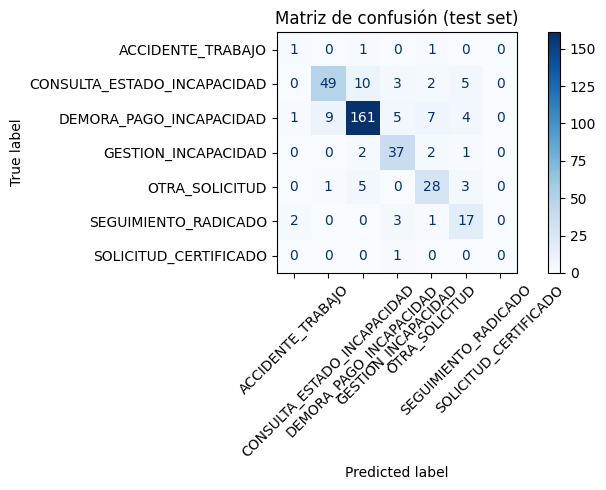

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 5))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión (test set)")
plt.tight_layout()
plt.show()

## 5. Clasificación de nuevas quejas

Ejemplo de predicción automática de categorías para nuevas descripciones de quejas.

In [6]:
def clasificar_nuevas_quejas(df_nuevo, vectorizer, modelo):
    textos = df_nuevo["Descripción"].apply(limpiar_texto)
    X_vec = vectorizer.transform(textos)
    categorias = modelo.predict(X_vec)
    probs = modelo.predict_proba(X_vec)
    df_nuevo = df_nuevo.copy()
    df_nuevo["Categoria_Predicha"] = categorias
    df_nuevo["Probabilidad_Max"] = probs.max(axis=1).round(3)
    return df_nuevo

muestra = df.head(5)
resultado = clasificar_nuevas_quejas(muestra, vectorizer, modelo)
resultado[["Nombre del cliente", "Categoria_Predicha", "Probabilidad_Max"]]

,Nombre del cliente,Categoria_Predicha,Probabilidad_Max
0,JORGE MEJIA,CONSULTA_ESTADO_INCAPACIDAD,0.902
1,FERLEY GANAN,CONSULTA_ESTADO_INCAPACIDAD,0.459
2,FABIAN LOPEZ,GESTION_INCAPACIDAD,0.285
3,SAMAN INVERSIONES S.A.S.,CONSULTA_ESTADO_INCAPACIDAD,0.910
4,JOSE CHAVERRA,DEMORA_PAGO_INCAPACIDAD,0.245


## 6. Interpretación de métricas

- **F1-Macro**: Promedia el F1-score de cada clase, útil para evaluar desempeño en clases desbalanceadas.
- **Matriz de confusión**: Permite identificar en qué categorías el modelo acierta o se confunde más.
- **Probabilidad máxima**: Indica el nivel de confianza del modelo en cada predicción.

Estas métricas y visualizaciones ayudan a interpretar la calidad del clasificador y sus posibles áreas de mejora.

In [7]:
import pickle

# Guardar modelo y vectorizador
with open("../outputs/modelo_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open("../outputs/modelo_lr.pkl", "wb") as f:
    pickle.dump(modelo, f)
print("Modelo y vectorizador guardados en ../outputs/")

# Cargar modelo y vectorizador
def cargar_modelo(path_prefix="../outputs/modelo"):
    with open(f"{path_prefix}_vectorizer.pkl", "rb") as f:
        vectorizer_loaded = pickle.load(f)
    with open(f"{path_prefix}_lr.pkl", "rb") as f:
        modelo_loaded = pickle.load(f)
    return vectorizer_loaded, modelo_loaded

vectorizer_loaded, modelo_loaded = cargar_modelo()
resultado_loaded = clasificar_nuevas_quejas(muestra, vectorizer_loaded, modelo_loaded)
resultado_loaded[["Nombre del cliente", "Categoria_Predicha", "Probabilidad_Max"]]

Modelo y vectorizador guardados en ../outputs/


,Nombre del cliente,Categoria_Predicha,Probabilidad_Max
0,JORGE MEJIA,CONSULTA_ESTADO_INCAPACIDAD,0.902
1,FERLEY GANAN,CONSULTA_ESTADO_INCAPACIDAD,0.459
2,FABIAN LOPEZ,GESTION_INCAPACIDAD,0.285
3,SAMAN INVERSIONES S.A.S.,CONSULTA_ESTADO_INCAPACIDAD,0.910
4,JOSE CHAVERRA,DEMORA_PAGO_INCAPACIDAD,0.245


## 7. Guardado y carga del modelo

A continuación se muestra cómo guardar y cargar el vectorizador y el modelo entrenado para su uso futuro.